In [10]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


##### Questions
- What is the frequency of the observations? <br>
The observations are monthly.
<br><br>

- How many observations are there in the dataset? <br>
To know, you can print the length of the dataframe:

In [4]:
# Solution
print(len(df))

144


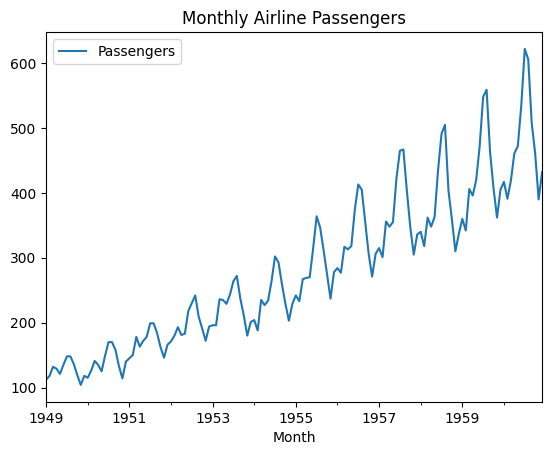

In [11]:
# Exercise 1: Solution
# Plot the time series
df.plot(title="Monthly Airline Passengers")
plt.show()

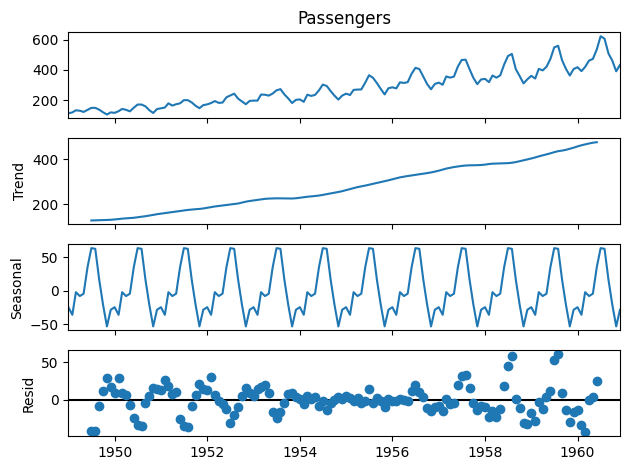

In [13]:
# Exercise 2
# Plot the components of the time series
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["Passengers"])
result.plot()
plt.show()

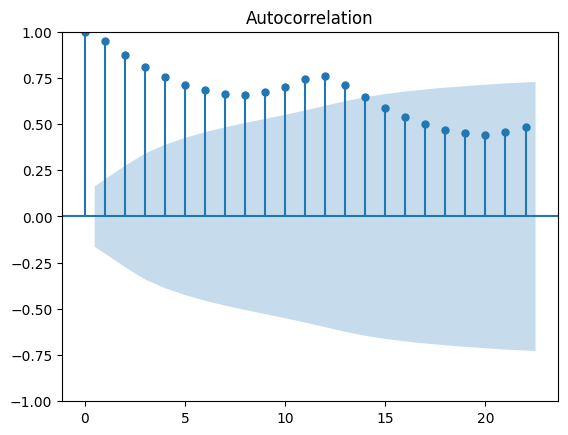

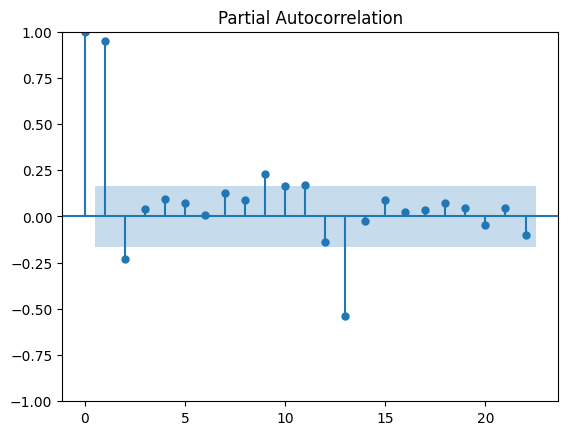

In [14]:
# Exercise 3
# Plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["Passengers"])
plot_pacf(df["Passengers"])
plt.show()

##### Questions
- What is stationarity?
- Is the time series stationary?
- What is the difference between ACF and PACF?

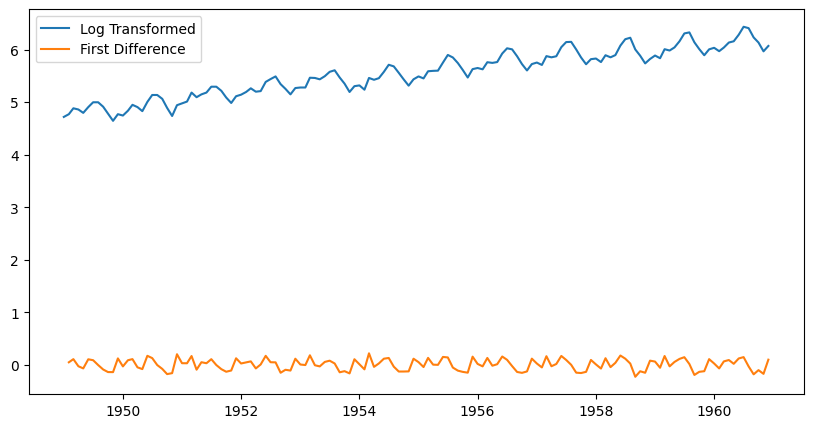

In [15]:
# Exercise 4
# If it is not already, make the time series stationary

import numpy as np

log_series = np.log(df["Passengers"])
diff_series = log_series.diff().dropna()

# Plot
plt.figure(figsize=(10,5))
plt.plot(log_series, label="Log Transformed")
plt.plot(diff_series, label="First Difference")
plt.legend()
plt.show()

/home/cgraiff/miniconda3/envs/transf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/cgraiff/miniconda3/envs/transf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/cgraiff/miniconda3/envs/transf_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


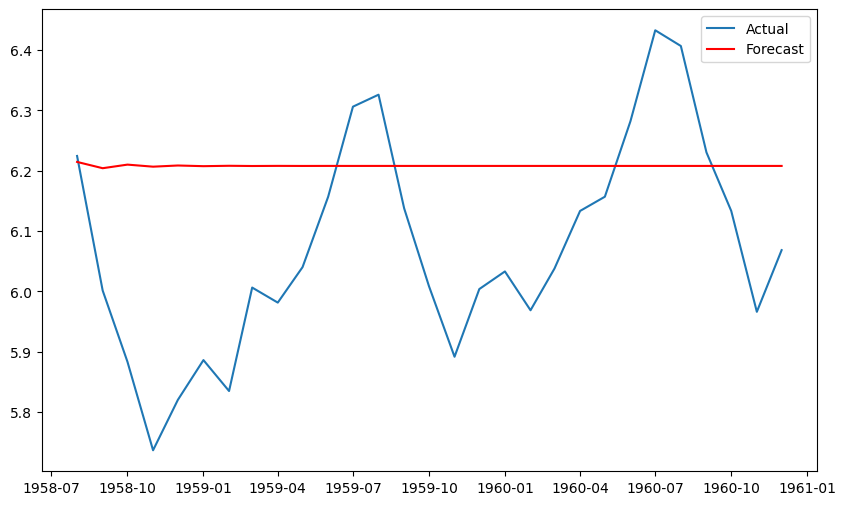

MAE: 0.1874


In [16]:
# Exercise 5
# Plot a time series model of your choice. Motivate the choice.

# Example: ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Split data
train_size = int(len(log_series) * 0.8)
train, test = log_series[:train_size], log_series[train_size:]

# Fit ARIMA (1,1,1)
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot forecast vs actual
plt.figure(figsize=(10,6))
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.show()

# MAE
mae = mean_absolute_error(test, forecast)
print(f"MAE: {mae:.4f}")